# Lab Assignment 15: Testing Hypotheses (2)

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**

- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods!

**Recommended Readings**:

* [Sampling Methods Guide](https://drive.google.com/file/d/1UtNdxDdI5XphWvwgTjODiAUFwArpZtoK/view)
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)

In [27]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
texlive is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [28]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<!-- END QUESTION -->

## 1. Who is Older?

Data scientists have drawn a simple random sample of size 500 from a large population of adults. Each member of the population happened to identify as either "male" or "female". (Though many people identify outside of the gender binary, in this particular population of interest, each member happened to identify as either male or female.) Data was collected on several attributes of the sampled people, including age. The table `sampled_ages` contains one row for each person in the sample, with columns containing the individual's gender identity.

In [30]:
sampled_ages = Table.read_table('./DS/age.csv')
sampled_ages.show(5)

Gender,Age
male,23
male,29
male,29
female,49
female,33


**Question 1.1.** How many females were there in our sample? Please use the provided skeleton code. **(4 points)**

*Hint:* Keep in mind that `.group` sorts categories in alphabetical order!


In [31]:
num_females = sampled_ages.group('Gender').where('Gender', 'female').column('count').item(0)
num_females

260

**Question 1.2.** Complete the cell below so that `avg_male_vs_female` evaluates to `True` if the sampled males are older than the sampled females on average, and `False` otherwise. Use Python code to achieve this. **(4 points)**


In [32]:
group_mean_tbl = sampled_ages.group('Gender', np.mean)
group_means = group_mean_tbl.column('Age mean')       # array of mean ages
avg_male_vs_female = group_means.item(1) > group_means.item(0)
avg_male_vs_female

True

**Question 1.3.** The data scientists want to use the data to test whether males are older than females—or, in other words, whether the ages of the two groups have the same distribution. One of the following statements is their null hypothesis and another is their alternative hypothesis. Assign `null_statement_number` and `alternative_statement_number` to the numbers of the correct statements in the code cell below. **(4 points)**

1. In the sample, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
2. In the population, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
3. The age distributions of males and females in the population are different due to chance.
4. The males in the sample are older than the females, on average.
5. The males in the population are older than the females, on average.
6. The average ages of the males and females in the population are different.


In [33]:
null_statement_number = 2
alternative_statement_number = 5

**Question 1.4.** The data scientists have decided to use a permutation test. Assign `permutation_test_reason` to the number corresponding to the reason they made this choice. **(4 points)**

1. Since a person's age shouldn't be related to their gender, it doesn't matter who is labeled "male" and who is labeled "female", so you can use permutations.
2. Under the null hypothesis, permuting the labels in the `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.
3. Under the null hypothesis, permuting the rows of `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.

*Note:* Check out [12.1](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#permutation-test) for a refresher on random permutations and permutation tests.


In [34]:
permutation_test_reason = 2
permutation_test_reason

2

**Question 1.5.** To test their hypotheses, the data scientists have followed our textbook's advice and chosen a test statistic where the following statement is true: Large values of the test statistic favor the alternative hypothesis.

The data scientists' test statistic is one of the two options below. Which one is it? Assign the appropriate number to the variable `correct_test_stat`. **(4 points)**

1. "male age average - female age average" in a sample created by randomly shuffling the male/female labels
2. "|male age average - female age average|" in a sample created by randomly shuffling the male/female labels


In [35]:
correct_test_stat = 1
correct_test_stat

1

**Question 1.6.** Complete the cell below so that `observed_statistic_ab` evaluates to the observed value of the data scientists' test statistic. Use as many lines of code as you need, and remember that you can use any quantity, table, or array that you created earlier. **(4 points)**


In [36]:
observed_statistic_ab = sampled_ages.group('Gender', np.mean).column('Age mean').item(1) - sampled_ages.group('Gender', np.mean).column('Age mean').item(0)
observed_statistic_ab

1.314102564102562

**Question 1.7.** Assign `shuffled_labels` to an array of shuffled male/female labels. The rest of the code puts the array in a table along with the data in `sampled_ages`. **(4 points)**


In [37]:
shuffled_labels = sampled_ages.sample(with_replacement=False).column('Gender')
original_with_shuffled_labels = sampled_ages.with_columns('Shuffled Label', shuffled_labels)
original_with_shuffled_labels

Gender,Age,Shuffled Label
male,23,male
male,29,male
male,29,female
female,49,female
female,33,female
male,31,female
male,60,female
male,38,female
female,60,male
female,27,male


**Question 1.8.** The comparison below uses the array `shuffled_labels` from Question 3.7 and the count `num_females` from Question 3.1.

For this comparison, assign the correct letter as a string (e.g. `correct_q8 = 'A'`) from one of the following options to the variable `correct_q8`. **Pretend this is a midterm problem and do not solve it using a code cell.** **(4 points)**

`comp = np.count_nonzero(shuffled_labels == 'female') == num_females`

A. `comp` is set to `True`.<br>
B. `comp` is set to `False`.<br>
C. `comp` is set to `True` or `False`, depending on how the shuffle came out.


In [38]:
correct_q8 = 'A'
correct_q8

'A'

**Question 1.9.** Define a function `simulate_one_statistic` that takes no arguments and returns one simulated value of the test statistic. We've given you a skeleton, but feel free to approach this question in a way that makes sense to you. Use as many lines of code as you need. Refer to the code you have previously written in this problem, as you might be able to re-use some of it. **(4 points)**


In [39]:
def simulate_one_statistic():
    "Returns one value of our simulated test statistic"
    shuffled_labels = sampled_ages.sample(with_replacement=False).column('Gender')
    shuffled_tbl = sampled_ages.with_columns('Shuffled Label', shuffled_labels)
    group_means = shuffled_tbl.group('Shuffled Label', np.mean).column('Age mean')
    return group_means.item(1) - group_means.item(0)

After you have defined your function, run the following cell a few times to see how the statistic varies.

In [40]:
simulate_one_statistic()

0.2964743589743577

**Question 1.10.** Complete the cell to simulate 5,000 values of the statistic. We have included the code that draws the empirical distribution of the statistic and shows the value of `observed_statistic_ab` from Question 3.6. Feel free to use as many lines of code as you need. **(4 points)**

*Note:* This cell will take around a minute to run.


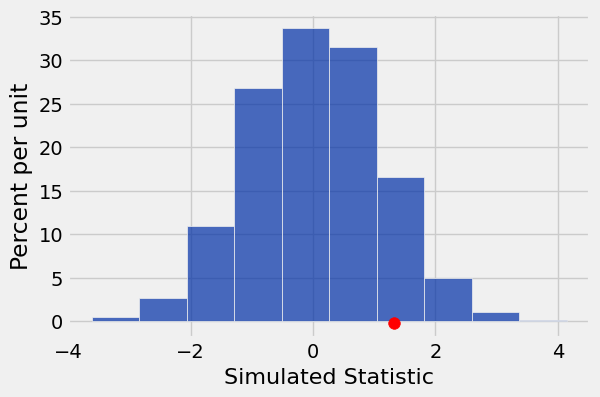

In [41]:
simulated_statistics_ab = make_array()

for i in np.arange(5000):
    simulated_statistics_ab = np.append(simulated_statistics_ab, simulate_one_statistic())

# Do not change these lines
Table().with_columns('Simulated Statistic', simulated_statistics_ab).hist()
plt.scatter(observed_statistic_ab, -0.002, color='red', s=70);

**Question 1.11.** Use the simulation to find an empirical approximation to the p-value. Assign `p_val` to the appropriate p-value from this simulation. Then, assign `conclusion` to either `null_hyp` or `alt_hyp`. **(4 points)**

*Note:* Assume that we use the 5% cutoff for the p-value.


In [42]:
# These are variables provided for you to use.
null_hyp = 'The data are consistent with the null hypothesis.'
alt_hyp = 'The data support the alternative more than the null.'

p_val = np.count_nonzero(simulated_statistics_ab >= observed_statistic_ab) / 5000

if p_val <= 0.05:
    conclusion = alt_hyp
else:
    conclusion = null_hyp

p_val, conclusion # Do not change this line

(0.1208, 'The data are consistent with the null hypothesis.')

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [44]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab15(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab15(SSU).ipynb to pdf
[NbConvertApp] Writing 50145 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 65646 bytes to DS/lab15(SSU).pdf
